## Obiettivo
Classificare logs del traffico di rete

## Dataset
- Utilizzeremo il dataset "Web Network" da Kaggle
- Il dataset contiene logs di traffico di rete
- Target: predire le richieste web come buone o cattive (`class`)

In [1]:
#!pip install kagglehub

In [2]:
import pandas as pd
import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
import kagglehub
# Download latest version
path = kagglehub.dataset_download("willianoliveiragibin/web-network")
print("Path to dataset files:", path)

Path to dataset files: C:\Users\miche\.cache\kagglehub\datasets\willianoliveiragibin\web-network\versions\2


In [4]:
df=pd.read_csv(path+"/test traficct new.csv")


In [5]:
df

,method,path,single_q,double_q,dashes,braces,spaces,percentages,semicolons,angle_brackets,...,percentages.1,semicolons.1,angle_brackets.1,special_chars.1,path_length.1,body_length.1,badwords_count.1,class,features,prediction
0,POST,/doLogin,0,0,0,0,0,0,0,0,...,0,0,0,0,8,33,1,1,"[0, 0, 0, 0, 0, 0, 0, 0, 2, 8, 33, 0]",0
1,POST,/sendFeedback,0,0,0,0,7,0,0,0,...,0,0,0,0,13,124,0,1,"[0, 0, 0, 0, 7, 0, 0, 0, 5, 13, 124, 0]",1
2,GET,/admin/clients.xls,0,0,0,0,0,0,0,0,...,0,0,0,0,18,0,1,1,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 18, 3, 0]",0
3,GET,/my%20documents/JohnSmith/Bank%20Site%20Docume...,0,0,0,0,3,0,0,0,...,0,0,0,0,57,0,0,1,"[0, 0, 0, 0, 3, 0, 0, 0, 0, 57, 3, 0]",1
4,GET,/my%20documents/JohnSmith/Bank%20Site%20Docume...,0,0,0,0,3,0,0,0,...,0,0,0,0,82,0,0,1,"[0, 0, 0, 0, 3, 0, 0, 0, 0, 82, 3, 0]",1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
517,0,0,0,0,0,0,0,0,0,0,...,0,0,2,0,80,0,2,1,"[2, 2, 0, 1, 1, 12, 0, 2, 0, 80, 3, 0]",1
518,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,49,0,1,1,"[2, 0, 0, 1, 0, 7, 0, 1, 0, 49, 3, 0]",1
519,0,0,0,0,0,0,0,0,0,0,...,0,0,8,0,8,275,6,1,"[2, 14, 0, 3, 7, 55, 0, 8, 5, 8, 275, 0]",1
520,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,11,0,0,1,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 11, 3, 0]",0


In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 522 entries, 0 to 521
Data columns (total 29 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   method            522 non-null    str  
 1   path              522 non-null    str  
 2   single_q          522 non-null    int64
 3   double_q          522 non-null    int64
 4   dashes            522 non-null    int64
 5   braces            522 non-null    int64
 6   spaces            522 non-null    int64
 7   percentages       522 non-null    int64
 8   semicolons        522 non-null    int64
 9   angle_brackets    522 non-null    int64
 10  special_chars     522 non-null    int64
 11  path_length       522 non-null    int64
 12  body_length       522 non-null    int64
 13  badwords_count    522 non-null    int64
 14  single_q.1        522 non-null    int64
 15  double_q.1        522 non-null    int64
 16  dashes.1          522 non-null    int64
 17  braces.1          522 non-null    int64
 18  s

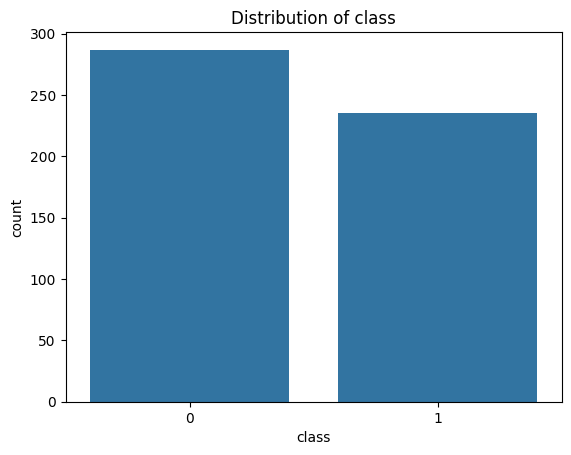

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.countplot(x='class', data=df)
plt.title('Distribution of class')
plt.show()

In [8]:
# Cerchiamo i valori nulli
missing_values = df.isna().sum()
missing_values

method              0
path                0
single_q            0
double_q            0
dashes              0
braces              0
spaces              0
percentages         0
semicolons          0
angle_brackets      0
special_chars       0
path_length         0
body_length         0
badwords_count      0
single_q.1          0
double_q.1          0
dashes.1            0
braces.1            0
spaces.1            0
percentages.1       0
semicolons.1        0
angle_brackets.1    0
special_chars.1     0
path_length.1       0
body_length.1       0
badwords_count.1    0
class               0
features            0
prediction          0
dtype: int64

In [13]:
from sklearn.model_selection import train_test_split

y = df['class']

X = df.drop(['class', 'features', 'prediction'], axis=1)
X = X.select_dtypes(include=[np.number])

# Split train / test 
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (417, 24)
Test: (105, 24)


In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


from sklearn.feature_selection import VarianceThreshold

# calcolo i valori di varianza e li ordiniamo dal più piccolo al più grande
variances = X_train.var().sort_values()
print(variances.head(30))   # le più basse

print(variances.tail(5))   # le più alte

single_q               0.000000
double_q               0.000000
dashes                 0.000000
braces                 0.000000
percentages            0.000000
semicolons             0.000000
angle_brackets         0.000000
special_chars          0.000000
special_chars.1        0.000000
percentages.1          0.000000
badwords_count         0.041793
dashes.1               0.098379
semicolons.1           0.511944
angle_brackets.1       0.640807
braces.1               0.712899
spaces                 0.823268
badwords_count.1       1.853798
double_q.1             2.077719
single_q.1             2.154757
spaces.1              28.698683
body_length          246.557323
path_length          435.464063
path_length.1       2374.913738
body_length.1       3298.526390
dtype: float64
spaces.1           28.698683
body_length       246.557323
path_length       435.464063
path_length.1    2374.913738
body_length.1    3298.526390
dtype: float64


In [16]:
threshold = 0.02
selected_features = variances[variances > threshold].index
X_train_var = X_train[selected_features]
X_test_var = X_test[selected_features]

X_train_var

,badwords_count,dashes.1,semicolons.1,angle_brackets.1,braces.1,spaces,badwords_count.1,double_q.1,single_q.1,spaces.1,body_length,path_length,path_length.1,body_length.1
336,0,0,0,0,0,0,0,0,0,0,0,0,10,0
174,0,0,0,0,1,0,1,2,0,0,0,0,70,0
375,0,0,0,0,0,0,0,0,0,0,0,0,39,0
74,0,0,0,0,0,0,1,0,0,0,0,39,8,65
126,0,1,1,0,1,0,4,2,4,14,0,0,177,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
388,0,0,0,0,0,0,0,0,0,0,0,0,84,0
140,0,1,1,0,1,0,4,2,4,14,0,0,189,0
257,0,0,0,0,0,0,0,0,0,0,0,0,43,0
85,0,0,0,0,0,0,0,0,0,2,0,41,13,114


### Abbiamo 24 feature, non sono tantissime: in questa fase non ci interessiamo di feature selection in maniera troppo precisa.

Verifichiamo giusto che non ci siano feature ridondanti

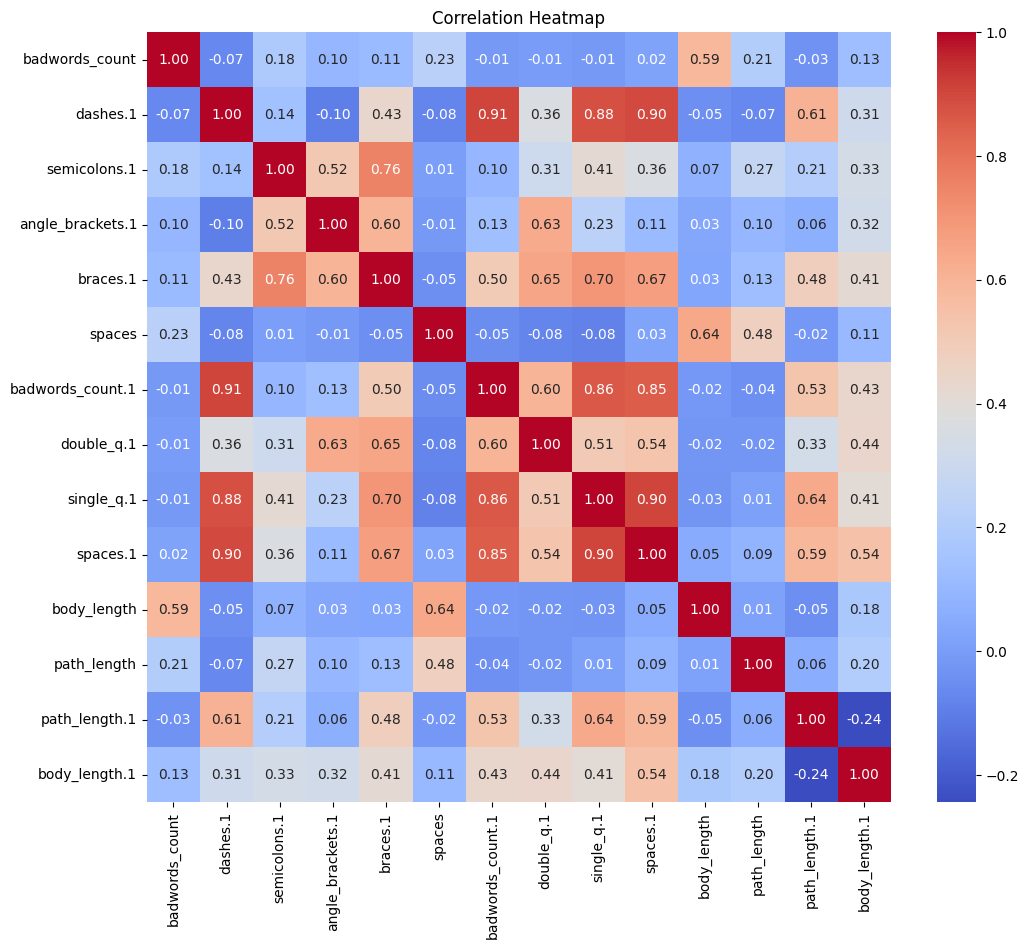

In [17]:
plt.figure(figsize=(12, 10))
sns.heatmap(X_train_var.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [18]:
corr_matrix = X_train_var.corr().abs()

# prendiamo solo la parte superiore (evita duplicati)
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# soglia
threshold = 0.85 #decidiamo la soglia di ridondanza tra features

# colonne da eliminare
to_drop = [column for column in upper.columns if any(upper[column] > 0.85)]

print("Feature rimosse per alta correlazione:")
print(to_drop)

# Applichiamo la selezione
X_train_reduced = X_train_var.drop(columns=to_drop)
X_test_reduced = X_test_var.drop(columns=to_drop)

print("Originale:")
print("X_train:", X_train.shape)

print("\nDopo rimozione varianza bassa:")
print("X_train_var:", X_train_var.shape)

print("\nDopo rimozione feature correlate:")
print("X_train_reduced:", X_train_reduced.shape)

Feature rimosse per alta correlazione:
['badwords_count.1', 'single_q.1', 'spaces.1']
Originale:
X_train: (417, 24)

Dopo rimozione varianza bassa:
X_train_var: (417, 14)

Dopo rimozione feature correlate:
X_train_reduced: (417, 11)


### Scaling

In [19]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_reduced)
X_test_scaled = scaler.transform(X_test_reduced)

E' davvero necessario per Naive Bayes?

❌ Non è necessario.

Lo scaling cambia la rappresentazione dei dati,
ma il modello ricalcola P(x|y), quindi la decisione finale resta invariata.

Possiamo continuare ad utilizzare X_train_reduced e X_test_reduced

# Risoluzione con Naive Bayes Manuale

Verifichiamo la distribuzione delle features.

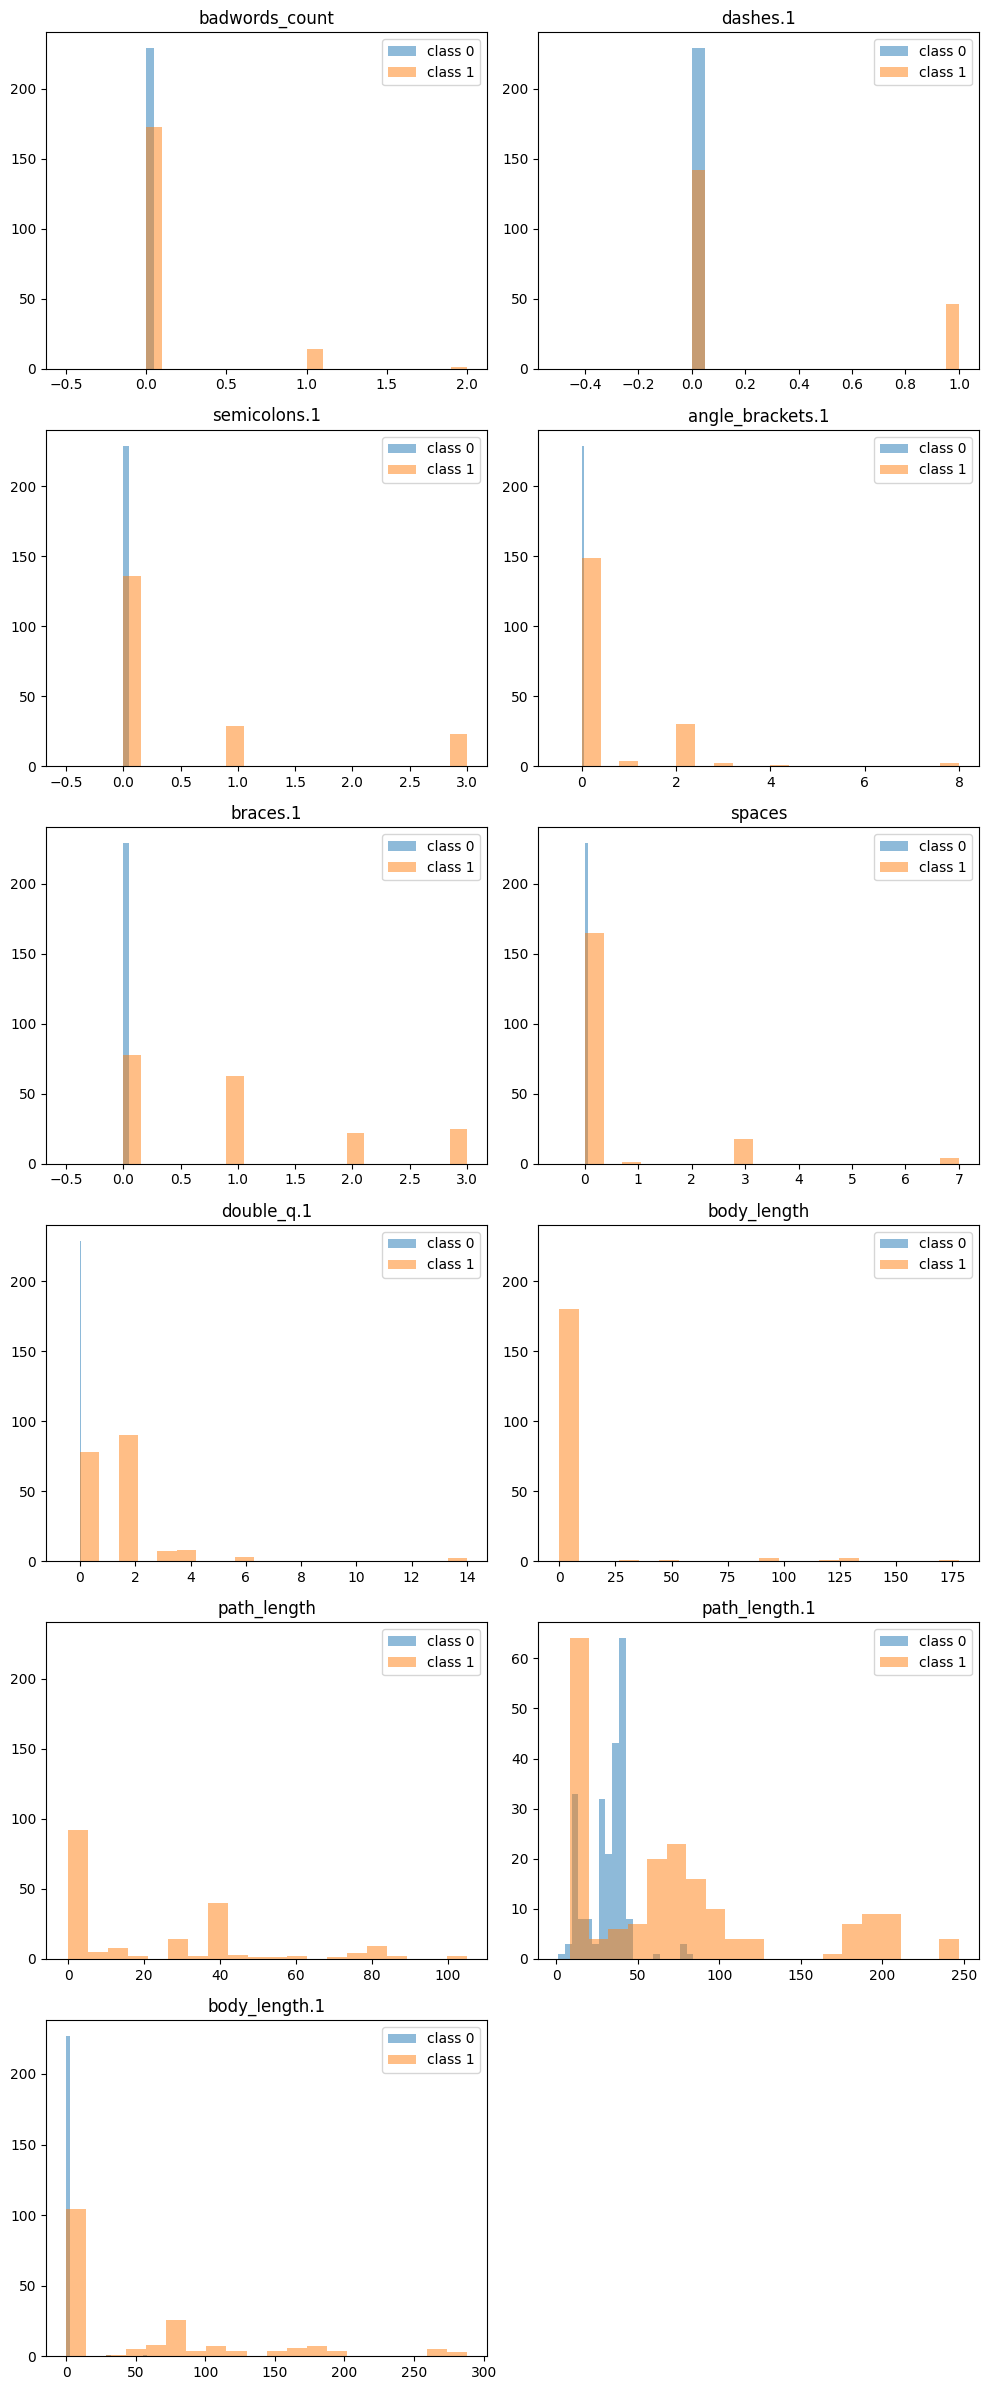

In [25]:
import matplotlib.pyplot as plt
import math

cols = X_train_reduced.columns
n_cols = 2
n_rows = math.ceil(len(cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(cols):
    ax = axes[i]
    for label in y_train.unique():
        subset = X_train_reduced[y_train == label]
        ax.hist(subset[col], bins=20, alpha=0.5, label=f"class {label}")
    ax.set_title(col)
    ax.legend()

# Nasconde eventuali subplot vuoti
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# Le distribuzioni sono gaussiane?

Come possiamo osservare dagli istogrammi, molte feature NON seguono una distribuzione gaussiana.

Questo NON significa che Gaussian Naive Bayes non funzioni:
l'obiettivo del modello è classificare correttamente, non modellare perfettamente la distribuzione.

Se le distribuzioni delle classi sono sufficientemente diverse,
il modello può comunque ottenere buone prestazioni.

### Assunzione Naive

Assumiamo indipendenza condizionata tra le feature:

P(x1,...,xD | y) ≈ Π P(xd | y)

In [42]:
import numpy as np
from scipy.stats import norm

class GaussianNaiveBayes:
    """
    Implementazione del Naive Bayes Gaussiano per caratteristiche continue.
    
    Il Naive Bayes Gaussiano assume che le feature continue seguano una 
    distribuzione normale (gaussiana) all'interno di ogni classe.
    
    Parametri:
    ----------
    var_smoothing : float, default=1e-9
        Valore aggiunto alle varianze per evitare divisioni per zero.
    """
    
    def __init__(self, var_smoothing=1e-9):
        self.var_smoothing = var_smoothing
        self.class_priors = {}  # Probabilità a priori delle classi
        self.means = {}         # Media per ogni feature per ogni classe
        self.variances = {}     # Varianza per ogni feature per ogni classe
        self.classes = None     # Classi possibili
        self.n_features = None  # Numero di feature
        
    def fit(self, X, y):
        """
        Addestra il classificatore Naive Bayes Gaussiano.
        
        Parametri:
        ----------
        X : array-like, shape (n_samples, n_features)
            Matrice delle feature continue.
        y : array-like, shape (n_samples,)
            Vettore delle classi.
        
        Returns:
        --------
        self : object
        """
        X = np.asarray(X)
        y = np.asarray(y)
        
        n_samples, self.n_features = X.shape
        self.classes = np.unique(y)
        
        # Calcolo delle probabilità a priori delle classi P(y=l)
        for c in self.classes:
            self.class_priors[c] = np.mean(y == c)
            self.means[c] = {}
            self.variances[c] = {}
            
            # Calcolo media e varianza per ogni feature per questa classe
            X_c = X[y == c]
            
            for feature_idx in range(self.n_features):
                feature_values = X_c[:, feature_idx]
                
                # Calcolo media
                self.means[c][feature_idx] = np.mean(feature_values)
                
                # Calcolo varianza (con smoothing)
                self.variances[c][feature_idx] = np.var(feature_values) + self.var_smoothing
        
        return self
    
    def _calculate_gaussian_log_probability(self, x, mean, variance):
        """
        Calcola la densità di probabilità gaussiana.
        
        Parametri:
        ----------
        x : float
            Valore di cui calcolare la probabilità.
        mean : float
            Media della distribuzione gaussiana.
        variance : float
            Varianza della distribuzione gaussiana.
        
        Returns:
        --------
        float : Densità di probabilità calcolata.
        """
        return -0.5 * np.log(2 * np.pi * variance) - ((x - mean) ** 2) / (2 * variance)

    def predict_log_proba(self, X):
        """
        Calcola il logaritmo delle probabilità per ciascuna classe. <- per evitare che la produttoria di probabilità porti ad underflow
        
        Parametri:
        ----------
        X : array-like, shape (n_samples, n_features)
            Matrice delle feature continue.
        
        Returns:
        --------
        array, shape (n_samples, n_classes) : Log-probabilità per ogni classe.
        """
        X = np.asarray(X)
        n_samples = X.shape[0]
        n_classes = len(self.classes)
        log_probs = np.zeros((n_samples, n_classes))
        
        for i in range(n_samples):
            for j, c in enumerate(self.classes):
                # Probabilità a priori (in log-spazio)
                log_prob = np.log(self.class_priors[c])
                
                # Somma dei logaritmi delle probabilità condizionate
                for feature_idx in range(self.n_features):
                    x_value = X[i, feature_idx]
                    mean = self.means[c][feature_idx]
                    variance = self.variances[c][feature_idx]
                    log_prob += self._calculate_gaussian_log_probability(
                        x_value, mean, variance)    
                
                log_probs[i, j] = log_prob
        
        return log_probs
    
    def predict_proba(self, X):
        """
        Restituisce le probabilità normalizzate delle classi.
        NON è necessaria, perchè ci interessa il massimo nel numeratore (predict_log_proba), 
        ma può essere utile per interpretabilità:
          ci da le probabilità vere
          posso applicare soglie (è spam solo se P>0.9)
          posso applicare metriche avanzate (tipo ROC)
        
        Parametri:
        ----------
        X : array-like, shape (n_samples, n_features)
            Matrice delle feature continue.
        
        Returns:
        --------
        array, shape (n_samples, n_classes) : Probabilità per ogni classe.
        """
        log_probs = self.predict_log_proba(X)
        
        # Normalizzazione numericamente stabile (log-sum-exp trick)
        log_prob_max = np.max(log_probs, axis=1).reshape(-1, 1)
        probs = np.exp(log_probs - log_prob_max)
        probs_sum = np.sum(probs, axis=1).reshape(-1, 1)
        
        return probs / probs_sum
    
    def predict(self, X):
        """
        Predice le classi per i campioni in X.
        
        Parametri:
        ----------
        X : array-like, shape (n_samples, n_features)
            Matrice delle feature continue.
        
        Returns:
        --------
        array, shape (n_samples,) : Le classi predette.
        """
        probs = self.predict_proba(X)
        return self.classes[np.argmax(probs, axis=1)]
    
    def score(self, X, y):
        """
        Calcola l'accuratezza del classificatore.
        
        Parametri:
        ----------
        X : array-like, shape (n_samples, n_features)
            Matrice delle feature continue di test.
        y : array-like, shape (n_samples,)
            Classi vere dei campioni di test.
        
        Returns:
        --------
        float : Accuratezza del classificatore.
        """
        return np.mean(self.predict(X) == y)

Accuracy score: 0.9809523809523809


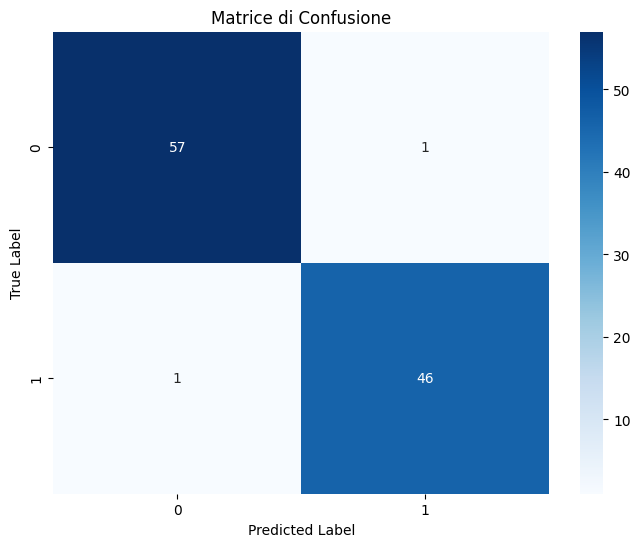

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# Creiamo e addestriamo il modello
nb_classifier = GaussianNaiveBayes()
nb_classifier.fit(X_train_reduced, y_train)

# Facciamo predizioni
y_pred = nb_classifier.predict(X_test_reduced)

# Valutiamo le performance
print("Accuracy score:", nb_classifier.score(X_test_reduced, y_test))

# Matrice di confusione
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Matrice di Confusione')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# Testiamo Bayes con il binning

In [32]:
class BinningNaiveBayes:
    """
    Implementazione del Naive Bayes con discretizzazione (binning) per caratteristiche continue.
    
    Parametri:
    ----------
    binning_method : str, default='equal_width'
        Metodo di binning da utilizzare ('equal_width' o 'equal_frequency').
    n_bins : int, default=5
        Numero di bin da creare per ogni caratteristica continua.
    smoothing : float, default=1.0
        Parametro di smoothing per evitare probabilità zero.
    """
    
    def __init__(self, binning_method='equal_width', n_bins=5, smoothing=1.0):
        self.binning_method = binning_method
        self.n_bins = n_bins
        self.smoothing = smoothing
        self.class_priors = {}     # Probabilità a priori delle classi
        self.feature_probs = {}    # Probabilità condizionate delle feature dato la classe
        self.classes = None        # Classi possibili
        self.features = None       # Caratteristiche disponibili
        self.bin_edges = {}        # Bordi dei bin per ogni caratteristica
    
    def fit(self, X, y):
        """
        Addestra il classificatore Naive Bayes con binning.
        
        Parametri:
        ----------
        X : DataFrame o array-like
            Matrice delle feature continue.
        y : Series o array-like
            Vettore delle classi.
        
        Returns:
        --------
        self : object
        """
        # Convertiamo in DataFrame per maggiore flessibilità
        if not isinstance(X, pd.DataFrame):
            X = pd.DataFrame(X)
        
        if not isinstance(y, pd.Series):
            y = pd.Series(y)
        
        self.classes = np.unique(y)
        self.features = X.columns if hasattr(X, 'columns') else range(X.shape[1])
        
        # Applichiamo il binning a ogni caratteristica
        X_binned = X.copy()
        for feature in self.features:
            data = X[feature].values
            
            if self.binning_method == 'equal_width':
                bins, bin_edges = equal_width_binning(data, n_bins=self.n_bins)
            else:  # equal_frequency
                bins, bin_edges = equal_frequency_binning(data, n_bins=self.n_bins)
            
            X_binned[feature] = bins
            self.bin_edges[feature] = bin_edges
        
        # Calcolo delle probabilità a priori delle classi
        for c in self.classes:
            self.class_priors[c] = np.mean(y == c)
            self.feature_probs[c] = {}
            
            # Calcolo delle probabilità condizionate per ogni feature discretizzata
            X_c = X_binned[y == c]
            for feature in self.features:
                self.feature_probs[c][feature] = {}
                
                # Contiamo la frequenza di ogni bin
                bin_counts = X_c[feature].value_counts()
                total_count = len(X_c)
                
                # Calcoliamo la probabilità di ogni bin con smoothing
                for bin_idx in range(self.n_bins):
                    count = bin_counts.get(bin_idx, 0)
                    # Applichiamo lo smoothing di Laplace
                    prob = (count + self.smoothing) / (total_count + self.n_bins * self.smoothing)
                    self.feature_probs[c][feature][bin_idx] = prob
        
        return self
    
    def predict_proba(self, X):
        """
        Restituisce le probabilità delle classi per i campioni in X.
        
        Parametri:
        ----------
        X : DataFrame o array-like
            Matrice delle feature continue.
        
        Returns:
        --------
        array, shape (n_samples, n_classes) : Le probabilità di ogni classe per ogni campione.
        """
        # Convertiamo in DataFrame per maggiore flessibilità
        if not isinstance(X, pd.DataFrame):
            X = pd.DataFrame(X, columns=self.features)
        
        # Applichiamo il binning a X
        X_binned = X.copy()
        for feature in self.features:
            data = X[feature].values
            bins = np.digitize(data, self.bin_edges[feature][1:-1])
            X_binned[feature] = bins
        
        n_samples = X.shape[0]
        n_classes = len(self.classes)
        probas = np.zeros((n_samples, n_classes))
        
        for i, sample in X_binned.iterrows():
            for j, c in enumerate(self.classes):
                # Probabilità a priori (in log-spazio per evitare underflow)
                log_prob = np.log(self.class_priors[c])
                
                # Prodotto delle probabilità condizionate per ogni feature
                for feature in self.features:
                    bin_idx = sample[feature]
                    # Ci assicuriamo che bin_idx sia un indice valido
                    bin_idx = min(max(bin_idx, 0), self.n_bins - 1)
                    feature_prob = self.feature_probs[c][feature][bin_idx]
                    
                    # Sommiamo i logaritmi
                    log_prob += np.log(feature_prob)
                
                probas[i % n_samples, j] = log_prob
        
        # Convertiamo da log-spazio a probabilità normalizzate
        log_prob_sum = np.array([self._logsumexp(probas[i % n_samples]) for i in range(n_samples)])
        probas = np.exp(probas - log_prob_sum.reshape(-1, 1))
        
        return probas
    
    def predict(self, X):
        """
        Predice le classi per i campioni in X.
        
        Parametri:
        ----------
        X : DataFrame o array-like
            Matrice delle feature continue.
        
        Returns:
        --------
        array, shape (n_samples,) : Le classi predette.
        """
        probas = self.predict_proba(X)
        return self.classes[np.argmax(probas, axis=1)]
    
    def score(self, X, y):
        """
        Calcola l'accuratezza del classificatore.
        
        Parametri:
        ----------
        X : DataFrame o array-like
            Matrice delle feature continue di test.
        y : Series o array-like
            Classi vere dei campioni di test.
        
        Returns:
        --------
        float : Accuratezza del classificatore.
        """
        return np.mean(self.predict(X) == y)
    
    def _logsumexp(self, a):
        """
        Calcola log(sum(exp(a))) in modo numericamente stabile.
        """
        a_max = np.max(a)
        return a_max + np.log(np.sum(np.exp(a - a_max)))

In [33]:
def equal_width_binning(data, n_bins=5):
    """
    Discretizza i dati usando il metodo equal-width binning.
    
    Parametri:
    ----------
    data : array-like
        Dati da discretizzare.
    n_bins : int, default=5
        Numero di bin da creare.
    
    Returns:
    --------
    bins : array
        Array con i valori discretizzati (indici dei bin).
    bin_edges : array
        Array con i bordi dei bin.
    """
    # Calcoliamo i bordi dei bin
    min_val = np.min(data)
    max_val = np.max(data)
    bin_edges = np.linspace(min_val, max_val, n_bins + 1)
    
    # Assegniamo ogni valore al bin corrispondente
    bins = np.digitize(data, bin_edges[1:-1])
    
    return bins, bin_edges

def equal_frequency_binning(data, n_bins=5):
    """
    Discretizza i dati usando il metodo equal-frequency binning.
    
    Parametri:
    ----------
    data : array-like
        Dati da discretizzare.
    n_bins : int, default=5
        Numero di bin da creare.
    
    Returns:
    --------
    bins : array
        Array con i valori discretizzati (indici dei bin).
    bin_edges : array
        Array con i bordi dei bin.
    """
    # Calcoliamo i quantili
    quantiles = np.linspace(0, 100, n_bins + 1)
    bin_edges = np.percentile(data, quantiles)
    
    # Assegniamo ogni valore al bin corrispondente
    bins = np.digitize(data, bin_edges[1:-1])
    
    return bins, bin_edges


Accuratezza del Naive Bayes con Equal-Width Binning: 0.5333
Accuratezza del Naive Bayes con Equal-Frequency Binning: 0.5524


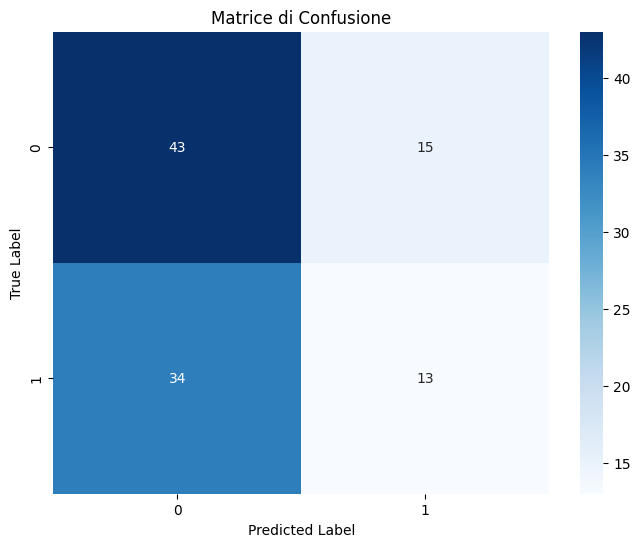

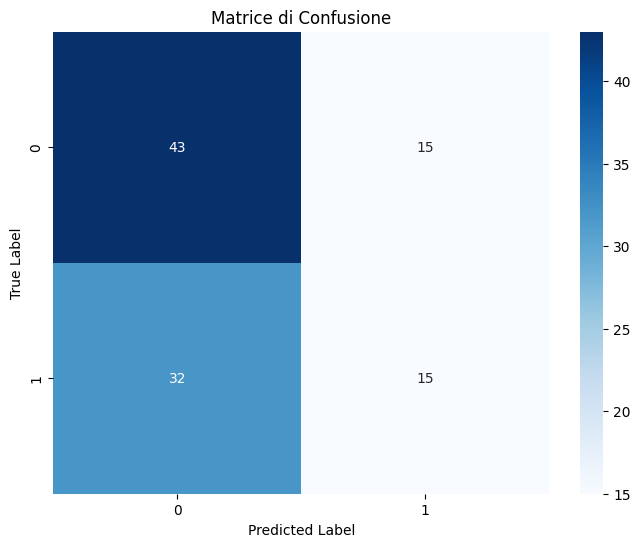

In [47]:
# Addestriamo e valutiamo il modello Naive Bayes con Equal-Width Binning
nb_equal_width = BinningNaiveBayes(binning_method='equal_width', n_bins=5, smoothing=1.0)
nb_equal_width.fit(X_train_reduced, y_train)
accuracy_equal_width = nb_equal_width.score(X_test_reduced, y_test)
y_pred_equal_width = nb_equal_width.predict(X_test_reduced)

# Addestriamo e valutiamo il modello Naive Bayes con Equal-Frequency Binning
nb_equal_freq = BinningNaiveBayes(binning_method='equal_frequency', n_bins=5, smoothing=1.0)
nb_equal_freq.fit(X_train_reduced, y_train)
accuracy_equal_freq = nb_equal_freq.score(X_test_reduced, y_test)
y_pred_equal_freq = nb_equal_freq.predict(X_test_reduced)


print(f"\nAccuratezza del Naive Bayes con Equal-Width Binning: {accuracy_equal_width:.4f}")
print(f"Accuratezza del Naive Bayes con Equal-Frequency Binning: {accuracy_equal_freq:.4f}")

# Matrice di confusione
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_equal_width)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Matrice di Confusione')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()


# Matrice di confusione
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_equal_freq)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Matrice di Confusione')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()


Il binning può essere utile quando non vogliamo assumere una forma parametrica per P(x|y), ma introduce una forte perdita di informazione. In questo dataset, le feature continue sembrano contenere informazione discriminante nella loro scala originale: discretizzarle in pochi intervalli peggiora drasticamente le prestazioni.

# GaussianNB in scikit-learn

Il modello implementa Naive Bayes con distribuzioni gaussiane per le feature continue.

Per ogni feature e classe, stima media e varianza,
assumendo indipendenza condizionata tra le feature.

Accuracy: 0.9809523809523809


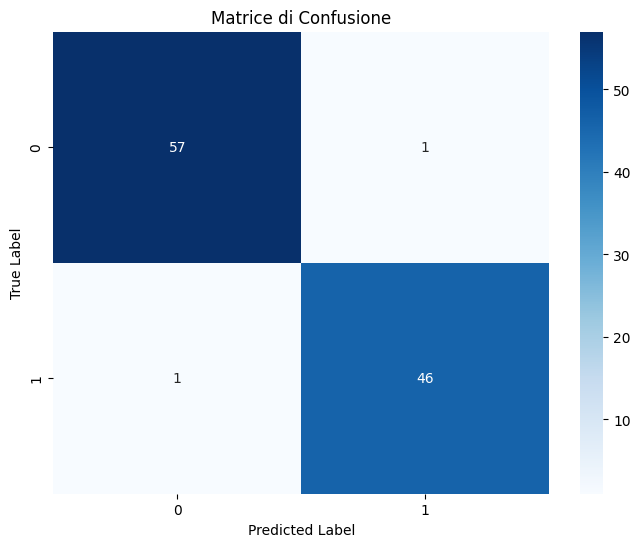

In [39]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


model = GaussianNB()
model.fit(X_train_reduced, y_train)

y_pred_sklearn = model.predict(X_test_reduced)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred_sklearn))

# Matrice di confusione
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_sklearn)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Matrice di Confusione')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

In [41]:
results = pd.DataFrame({
    "Modello": [
        "Manual Gaussian NB",
        "Sklearn GaussianNB",
        "Binning Equal Width",
        "Binning Equal Frequency"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_manual),
        accuracy_score(y_test, y_pred_sklearn),
        accuracy_equal_width,
        accuracy_equal_freq
    ]
})

results

NameError: name 'y_pred_manual' is not defined